# SIT307 Task 11.1HD – Machine Learning Mini Research
**Name:** Tuan Anh Dao  

**Student ID:** s224756723

**Email Address:** s224756723@deakin.edu.au

## Reproducing and Improving DASMcC (Sinha et al., IEEE Access 2023) on PTB-XL

- **Part 1:** Understanding and reproducing the published results (Sections 0–6)
- **Part 2:** Proposed solution – leakage-free evaluation with multi-lead median-beat features (Sections 7–8)
- Data: PTB-XL v1.0.3 (`ptbxl_database.csv`, `scp_statements.csv`, `records100/`)

# Setup

## Install dependencies

In [1]:
# Run once, then restart the kernel
%pip install wfdb neurokit2 imbalanced-learn xgboost catboost

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
import ast
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from joblib import Parallel, delayed

import wfdb
import neurokit2 as nk

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, balanced_accuracy_score, matthews_corrcoef,
                             confusion_matrix, precision_recall_fscore_support, roc_curve)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

## Configuration

In [3]:
# Paths (PTB-XL files are in the same folder as this notebook)
DATA_DIR = Path(os.environ.get("PTBXL_DIR", "."))
CACHE_DIR, FIG_DIR, RESULTS_DIR = Path("cache"), Path("figures"), Path("results")
for d in (CACHE_DIR, FIG_DIR, RESULTS_DIR):
    d.mkdir(exist_ok=True)

# Signal settings
FS = 100                    # 100 Hz version, as in the paper
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
PAPER_LEAD = "II"           # assumption A1
N_BEATS = 10                # assumption A4
DELINEATE_METHOD = "dwt"    # assumption A2 (NeuroKit2 default)

# Run settings
SEED = 42
N_JOBS = -1                 # set to 1 if parallel extraction fails on Windows
QUICK_RUN = False           # True = small subset to test the pipeline
QUICK_N = 1500
RUN_EXP_1B = True
MODELS_1B = ["KNN", "RF", "XGBoost", "GradientBoost", "CatBoost"]
PART2_MODELS = ["RF", "XGBoost"]

# Label encoding from Table 5 of the paper
CLASSES = ["NORM", "MI", "STTC", "HYP", "CD"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

np.random.seed(SEED)
print("PTB-XL found:", (DATA_DIR / "ptbxl_database.csv").exists())

PTB-XL found: True


## Helper functions with models

In [4]:
# The five classifiers of the paper (Section III-F)
# Hyper-parameters are not reported in the paper, so library defaults are used (assumption A5)
def make_models(seed=SEED):
    return {
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=N_JOBS),
        "RF": RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=N_JOBS),
        "XGBoost": XGBClassifier(n_estimators=100, tree_method="hist", eval_metric="mlogloss",
                                 random_state=seed, n_jobs=N_JOBS),
        "GradientBoost": GradientBoostingClassifier(random_state=seed),
        "CatBoost": CatBoostClassifier(random_seed=seed, verbose=0, thread_count=-1),
    }

## Helper functions for evaluation metrics

In [5]:
# Macro one-vs-rest AUC over the classes present in y_true
def macro_ovr_auc(y_true, y_proba):
    aucs = [roc_auc_score((y_true == k).astype(int), y_proba[:, k])
            for k in range(len(CLASSES)) if 0 < (y_true == k).sum() < len(y_true)]
    return float(np.mean(aucs)) if aucs else np.nan


# Overall metrics: the paper's five metrics (macro average, assumption A6) + Balanced Acc and MCC
def evaluate(y_true, y_pred, y_proba):
    labels = list(range(len(CLASSES)))
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
        "F1": f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
        "AUC": macro_ovr_auc(y_true, y_proba),
        "BalancedAcc": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

In [6]:
# Per-class precision, recall, F1 and AUC (same layout as Tables 6, 7, 9, 10, 11 of the paper)
def per_class_table(y_true, y_pred, y_proba):
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=range(len(CLASSES)), zero_division=0)
    auc = []
    for k in range(len(CLASSES)):
        yk = (y_true == k).astype(int)
        auc.append(roc_auc_score(yk, y_proba[:, k]) if 0 < yk.sum() < len(yk) else np.nan)
    index = [f"{c} ({i})" for i, c in enumerate(CLASSES)]
    return pd.DataFrame({"Precision": p, "Recall": r, "F1": f, "AUC": auc, "Support": s}, index=index).round(3)

## Helper functions for plots

In [7]:
# Plot one or more confusion matrices side by side
def plot_confusion_matrices(cms, titles, fname, normalize=False):
    fig, axes = plt.subplots(1, len(cms), figsize=(4.2 * len(cms), 4))
    for ax, cm, title in zip(np.atleast_1d(axes), cms, titles):
        m = cm / cm.sum(1, keepdims=True) if normalize else cm
        ax.imshow(m, cmap="Blues")
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                txt = f"{m[i, j]:.2f}" if normalize else f"{int(m[i, j])}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                        color="white" if m[i, j] > m.max() * 0.6 else "black")
        ax.set_xticks(range(5)); ax.set_xticklabels(CLASSES, fontsize=8)
        ax.set_yticks(range(5)); ax.set_yticklabels(CLASSES, fontsize=8)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title, fontsize=10)
    plt.tight_layout(); plt.savefig(FIG_DIR / fname, dpi=150); plt.show()

In [8]:
# One-vs-rest ROC curve for every class (same style as Fig. 8 of the paper)
def plot_multiclass_roc(y_true, y_proba, title, fname):
    plt.figure(figsize=(5.5, 4.5))
    for k, c in enumerate(CLASSES):
        yk = (y_true == k).astype(int)
        fpr, tpr, _ = roc_curve(yk, y_proba[:, k])
        plt.plot(fpr, tpr, label=f"{c} vs rest (AUC = {roc_auc_score(yk, y_proba[:, k]):.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title(title)
    plt.legend(fontsize=8); plt.tight_layout(); plt.savefig(FIG_DIR / fname, dpi=150); plt.show()

# Part 1: Verifying the Results Reported in the Paper
## 1.Understanding and Reproducing Published Machine Learning Results

## 1.1 Confusion matrices from Fig. 7 and overall results from Table 12

In [9]:
# Confusion matrices copied from Fig. 7 (rows = actual, columns = predicted; order NORM, MI, STTC, HYP, CD)
paper_cms = {
    "KNN": [[414, 547, 544, 118, 231], [28, 1748, 19, 4, 10], [22, 57, 1694, 4, 10],
            [0, 0, 0, 1796, 0], [15, 22, 28, 6, 1766]],
    "RF": [[1579, 92, 117, 7, 34], [150, 1547, 68, 2, 26], [127, 42, 1648, 6, 25],
           [5, 0, 4, 1819, 1], [77, 23, 26, 2, 1656]],
    "XGBoost": [[1716, 45, 50, 3, 15], [179, 1567, 34, 3, 10], [121, 26, 1685, 4, 12],
                [21, 0, 1, 1807, 0], [102, 9, 7, 1, 1665]],
    "GradientBoost": [[1624, 91, 81, 6, 52], [212, 1396, 129, 12, 60], [161, 74, 1501, 11, 40],
                      [46, 1, 10, 1732, 7], [121, 49, 49, 9, 1609]],
    "CatBoost": [[1621, 83, 90, 6, 54], [199, 1446, 80, 7, 77], [158, 73, 1518, 11, 27],
                 [48, 2, 4, 1739, 3], [108, 41, 37, 8, 1643]],
}

# Overall results reported in Table 12 (%)
paper_table12 = pd.DataFrame({
    "XGBoost": [92, 90, 93, 93], "RF": [91, 92, 92, 91], "CatBoost": [89, 86, 89, 89],
    "GradientBoost": [85, 87, 87, 88], "KNN": [83, 82, 83, 82]},
    index=["Precision", "Recall", "F1", "Accuracy"]).T

## 1.2 Recomputing the metrics from the paper's confusion matrices

In [10]:
rows = []
for name, cm in paper_cms.items():
    cm = np.array(cm)
    tp = np.diag(cm)
    prec, rec = tp / cm.sum(0), tp / cm.sum(1)
    f1 = 2 * prec * rec / (prec + rec)
    rows.append({"Model": name,
                 "Test size": cm.sum(),
                 "Samples per class": list(cm.sum(1)),
                 "Acc (Fig.7)": 100 * tp.sum() / cm.sum(),
                 "Prec (Fig.7)": 100 * prec.mean(),
                 "Rec (Fig.7)": 100 * rec.mean(),
                 "F1 (Fig.7)": 100 * f1.mean(),
                 "Acc (Table 12)": paper_table12.loc[name, "Accuracy"],
                 "Rec (Table 12)": paper_table12.loc[name, "Recall"],
                 "NORM recall (Fig.7)": 100 * rec[0]})

paper_check = pd.DataFrame(rows).set_index("Model").round(1)
paper_check.to_csv(RESULTS_DIR / "paper_check.csv")
paper_check

,Test size,Samples per class,Acc (Fig.7),Prec (Fig.7),Rec (Fig.7),F1 (Fig.7),Acc (Table 12),Rec (Table 12),NORM recall (Fig.7)
Model,,,,,,,,,
KNN,9083,"[1854, 1809, 1787, 1796, 1837]",81.7,83.0,82.0,78.1,82,82,22.3
RF,9083,"[1829, 1793, 1848, 1829, 1784]",90.8,91.0,90.8,90.9,91,92,86.3
XGBoost,9083,"[1829, 1793, 1848, 1829, 1784]",92.9,93.5,92.9,93.0,93,90,93.8
GradientBoost,9083,"[1854, 1809, 1787, 1796, 1837]",86.6,87.1,86.6,86.7,88,87,87.6
CatBoost,9083,"[1854, 1809, 1787, 1796, 1837]",87.7,88.2,87.7,87.8,89,86,87.4


# 2. Dataset: PTB-XL

## 2.1 Load metadata and map SCP codes to the five diagnostic superclasses

In [11]:
# Same aggregation as the official PTB-XL example code
def load_ptbxl_metadata(data_dir):
    df = pd.read_csv(data_dir / "ptbxl_database.csv", index_col="ecg_id")
    df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)
    scp = pd.read_csv(data_dir / "scp_statements.csv", index_col=0)
    scp = scp[scp["diagnostic"] == 1]
    df["superclasses"] = df["scp_codes"].apply(
        lambda codes: sorted({scp.loc[c, "diagnostic_class"] for c in codes if c in scp.index}))
    df["n_labels"] = df["superclasses"].apply(len)
    return df


meta_all = load_ptbxl_metadata(DATA_DIR)
print("Total records:", len(meta_all), "| patients:", meta_all["patient_id"].nunique())
print(meta_all["n_labels"].value_counts().sort_index())

Total records: 21799 | patients: 18869
n_labels
0      411
1    16244
2     4068
3      919
4      157
Name: count, dtype: int64


## 2.2 Keep single-label records (as in the paper)

In [12]:
# The paper removes multi-label and unlabelled records
meta = meta_all[meta_all["n_labels"] == 1].copy()
meta["label_name"] = meta["superclasses"].str[0]
meta["label"] = meta["label_name"].map(CLASS_TO_ID)

# Optional small stratified subset for a quick test run
if QUICK_RUN:
    meta, _ = train_test_split(meta, train_size=min(QUICK_N, len(meta) - 5),
                               stratify=meta["label"], random_state=SEED)
    meta = meta.sort_index()

y = meta["label"].to_numpy()
print("Single-label records:", len(meta), "| patients:", meta["patient_id"].nunique())

Single-label records: 16244 | patients: 14627


## 2.3 Class distribution

In [13]:
# Paper Table 3 counts multi-label records several times; ours are single-label only
paper_table3 = pd.Series({"NORM": 9528, "MI": 5486, "STTC": 5250, "HYP": 2655, "CD": 4907})
ours = meta["label_name"].value_counts().reindex(CLASSES)

dist = pd.DataFrame({"Paper Table 3": paper_table3,
                     "Single-label (ours)": ours,
                     "Share (%)": (100 * ours / ours.sum()).round(1)})
dist.to_csv(RESULTS_DIR / "class_distribution.csv")
print("Imbalance ratio NORM/HYP = %.1f" % (ours["NORM"] / ours["HYP"]))
dist

Imbalance ratio NORM/HYP = 17.0


,Paper Table 3,Single-label (ours),Share (%)
NORM,9528,9069,55.8
MI,5486,2532,15.6
STTC,5250,2400,14.8
HYP,2655,535,3.3
CD,4907,1708,10.5


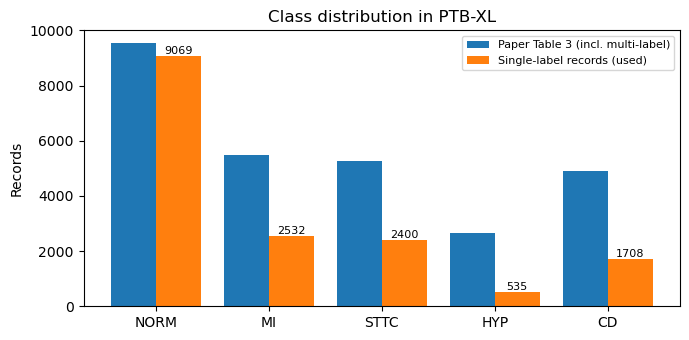

In [14]:
x = np.arange(len(CLASSES))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(x - 0.2, paper_table3[CLASSES], 0.4, label="Paper Table 3 (incl. multi-label)")
ax.bar(x + 0.2, ours[CLASSES], 0.4, label="Single-label records (used)")
for i, v in enumerate(ours[CLASSES]):
    ax.text(i + 0.2, v, str(v), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(CLASSES); ax.set_ylabel("Records")
ax.set_title("Class distribution in PTB-XL"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "class_distribution.png", dpi=150); plt.show()

# 3. Feature Extraction – The Paper's 16 Time-Series Features

## 3.1 Implementation assumptions
| # | Assumption |
|---|---|
| A1 | Features are extracted from lead II |
| A2 | NeuroKit2 default delineation method (DWT) |
| A3 | Intervals are computed between peaks: PQ = Q−P, PR = R−P, QRS = S−Q, ST = T−S, QT = T−Q, RR = R(i+1)−R(i) |
| A4 | The first 10 beats are kept; shorter records repeat the last beat → (N, 10, 16) → 160 columns |
| A5 | Default classifier hyper-parameters |
| A6 | Macro-averaged Precision / Recall / F1; one-vs-rest AUC |
| A7 | The unit of time intervals is the number of samples |
| A8 | Handle missing values using forward fill, even between records |

## 3.2 Signal loading and small utilities

In [15]:
PAPER_FEATURES = ["P_loc", "Q_loc", "R_loc", "S_loc", "T_loc",
                  "P_amp", "Q_amp", "R_amp", "S_amp", "T_amp",
                  "PQ", "ST", "QT", "PR", "RR", "QRS"]


# Read one 10 s, 100 Hz, 12-lead record -> array (1000, 12) in mV
def load_signal(filename_lr):
    sig, _ = wfdb.rdsamp(str(DATA_DIR / filename_lr))
    return sig.astype(np.float64)


# Convert a NeuroKit2 list (may contain NaN or be shorter) to a float array of length n
def aligned(values, n):
    out = np.full(n, np.nan)
    v = np.asarray(values, dtype=float)[:n]
    out[:len(v)] = v
    return out


# Signal amplitude at (possibly NaN) sample indices
def value_at(signal, idx):
    out = np.full(len(idx), np.nan)
    ok = ~np.isnan(idx)
    out[ok] = signal[idx[ok].astype(int)]
    return out

## 3.3 R-peak detection and P/Q/S/T delineation (NeuroKit2)

In [16]:
# Clean one lead, detect R-peaks and delineate the P, Q, S, T waves
def delineate_lead(x, fs=FS):
    clean = nk.ecg_clean(x, sampling_rate=fs)
    _, info = nk.ecg_peaks(clean, sampling_rate=fs)
    r = np.asarray(info["ECG_R_Peaks"], dtype=float)
    if len(r) < 3:
        return clean, r, None
    _, waves = nk.ecg_delineate(clean, r.astype(int), sampling_rate=fs, method=DELINEATE_METHOD)
    return clean, r, waves

## 3.4 The 16 features per beat (Table 4 of the paper)

In [17]:
# 5 peak locations + 5 peak amplitudes + 6 peak-to-peak intervals (in samples; 1 sample = 10 ms)
def paper_beat_features(x, fs=FS):
    clean, r, waves = delineate_lead(x, fs)
    if waves is None:
        return np.full((1, 16), np.nan)
    n = len(r)
    P = aligned(waves["ECG_P_Peaks"], n)
    Q = aligned(waves["ECG_Q_Peaks"], n)
    S = aligned(waves["ECG_S_Peaks"], n)
    T = aligned(waves["ECG_T_Peaks"], n)
    locs = [P, Q, r, S, T]
    amps = [value_at(clean, v) for v in locs]
    rr = np.append(np.diff(r), np.nan)               # RR of the last beat is unknown
    intervals = [Q - P, T - S, T - Q, r - P, rr, S - Q]  # PQ, ST, QT, PR, RR, QRS
    return np.column_stack(locs + amps + intervals)

## 3.5 Missing values and equal length ("length equated")

In [18]:
# Forward/backward fill inside the record, then truncate or pad (repeat last beat) to n_beats rows
def equalise_beats(beats, n_beats=N_BEATS):
    arr = pd.DataFrame(beats).ffill().bfill().to_numpy()
    if len(arr) >= n_beats:
        return arr[:n_beats]
    return np.vstack([arr, np.repeat(arr[-1:], n_beats - len(arr), axis=0)])


# Full pipeline for one record (used in parallel)
def extract_paper_record(filename_lr):
    warnings.filterwarnings("ignore")
    try:
        lead = load_signal(filename_lr)[:, LEADS.index(PAPER_LEAD)]
        beats = paper_beat_features(lead)
    except Exception:
        beats = np.full((1, 16), np.nan)
    return equalise_beats(beats)

## 3.6 Example: peak detection on one record (similar to Fig. 3 and Fig. 4)

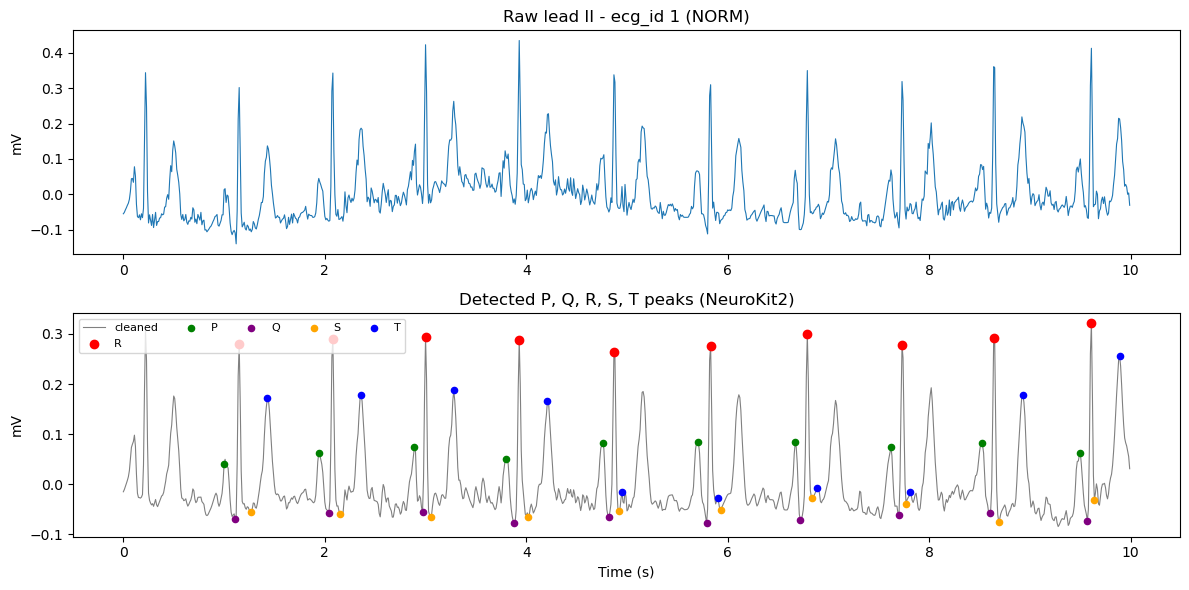

In [19]:
demo = meta.iloc[0]
lead_ii = load_signal(demo["filename_lr"])[:, LEADS.index(PAPER_LEAD)]
clean_demo, r_demo, waves_demo = delineate_lead(lead_ii)
t = np.arange(len(clean_demo)) / FS

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(t, lead_ii, lw=0.8)
ax[0].set_title(f"Raw lead II - ecg_id {demo.name} ({demo['label_name']})"); ax[0].set_ylabel("mV")
ax[1].plot(t, clean_demo, lw=0.8, color="grey", label="cleaned")
ax[1].scatter(r_demo / FS, clean_demo[r_demo.astype(int)], c="red", label="R", zorder=3)
for lab, col in zip(["P", "Q", "S", "T"], ["green", "purple", "orange", "blue"]):
    idx = aligned(waves_demo[f"ECG_{lab}_Peaks"], len(r_demo))
    idx = idx[~np.isnan(idx)].astype(int)
    ax[1].scatter(idx / FS, clean_demo[idx], s=20, c=col, label=lab, zorder=3)
ax[1].set_xlabel("Time (s)"); ax[1].set_ylabel("mV"); ax[1].legend(ncol=5, fontsize=8)
ax[1].set_title("Detected P, Q, R, S, T peaks (NeuroKit2)")
plt.tight_layout(); plt.savefig(FIG_DIR / "peak_detection_demo.png", dpi=150); plt.show()

## 3.7 Example: extracted intervals per beat (similar to Fig. 5)

,P_loc,Q_loc,R_loc,S_loc,T_loc,P_amp,Q_amp,R_amp,S_amp,T_amp,PQ,ST,QT,PR,RR,QRS
0,100.0,111.0,115.0,127.0,143.0,0.040,-0.069,0.279,-0.056,0.172,11.0,16.0,32.0,15.0,93.0,16.0
1,194.0,204.0,208.0,215.0,236.0,0.063,-0.057,0.290,-0.060,0.179,10.0,21.0,32.0,14.0,92.0,11.0
2,289.0,297.0,300.0,305.0,328.0,0.075,-0.055,0.293,-0.066,0.187,8.0,23.0,31.0,11.0,93.0,8.0
3,380.0,388.0,393.0,402.0,421.0,0.051,-0.077,0.287,-0.065,0.166,8.0,19.0,33.0,13.0,94.0,14.0
4,476.0,482.0,487.0,492.0,495.0,0.081,-0.066,0.263,-0.054,-0.016,6.0,3.0,13.0,11.0,96.0,10.0
5,570.0,579.0,583.0,593.0,590.0,0.084,-0.078,0.277,-0.051,-0.028,9.0,-3.0,11.0,13.0,96.0,14.0
6,667.0,672.0,679.0,684.0,689.0,0.083,-0.072,0.299,-0.027,-0.009,5.0,5.0,17.0,12.0,94.0,12.0
7,762.0,770.0,773.0,777.0,781.0,0.073,-0.061,0.278,-0.039,-0.015,8.0,4.0,11.0,11.0,91.0,7.0
8,852.0,860.0,864.0,869.0,893.0,0.082,-0.058,0.293,-0.075,0.178,8.0,24.0,33.0,12.0,97.0,9.0
9,950.0,957.0,961.0,964.0,989.0,0.062,-0.073,0.321,-0.031,0.256,7.0,25.0,32.0,11.0,NaN,7.0


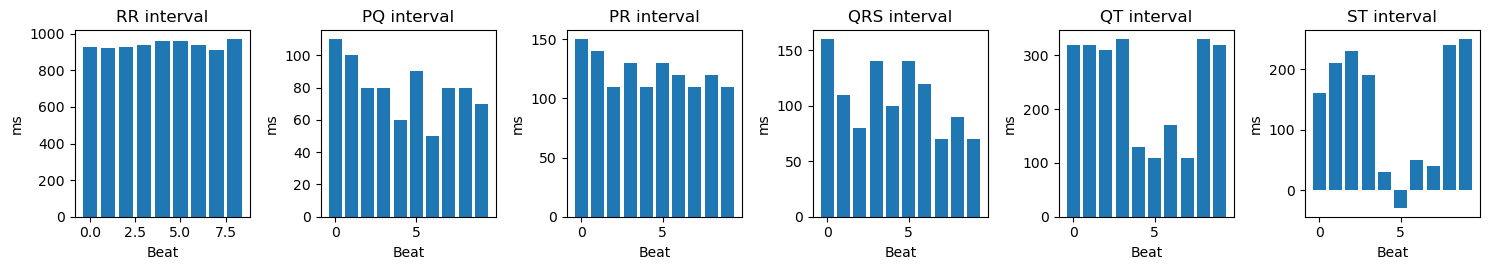

In [20]:
beats_demo = pd.DataFrame(paper_beat_features(lead_ii), columns=PAPER_FEATURES)
display(beats_demo.round(3))

fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
for ax, col in zip(axes, ["RR", "PQ", "PR", "QRS", "QT", "ST"]):
    ax.bar(range(len(beats_demo)), beats_demo[col] * 1000 / FS)
    ax.set_title(f"{col} interval"); ax.set_xlabel("Beat"); ax.set_ylabel("ms")
plt.tight_layout(); plt.savefig(FIG_DIR / "intervals_demo.png", dpi=150); plt.show()

## 3.8 Extract features for all records (cached)

In [21]:
# Cache file name depends on the run settings
def cache_name(prefix):
    tag = f"quick{QUICK_N}" if QUICK_RUN else "full"
    return CACHE_DIR / f"{prefix}_{tag}_lead{PAPER_LEAD}_beats{N_BEATS}.npz"


# Load features from cache, or extract them in parallel and save
def get_features(prefix, extract_fn):
    path = cache_name(prefix)
    if path.exists():
        z = np.load(path)
        assert np.array_equal(z["ecg_id"], meta.index.to_numpy()), "Cache mismatch - delete the cache folder"
        print("Loaded from cache:", z["X"].shape)
        return z["X"]
    t0 = time.time()
    X = np.stack(Parallel(n_jobs=N_JOBS, batch_size=32)(
        delayed(extract_fn)(fn) for fn in meta["filename_lr"]))
    np.savez_compressed(path, X=X, ecg_id=meta.index.to_numpy())
    print(f"Extracted {X.shape} in {(time.time() - t0) / 60:.1f} min")
    return X


X_paper_3d = get_features("paper_features", extract_paper_record)   # (n_records, N_BEATS, 16)

Loaded from cache: (16244, 10, 16)


## 3.9 Data preparation: forward fill and flatten (Section III-D)

In [22]:
all_nan = np.isnan(X_paper_3d).all(axis=(1, 2))
print(f"Records where delineation failed completely: {all_nan.sum()} ({100 * all_nan.mean():.2f}%)")

# Flatten (N, N_BEATS, 16) -> (N, N_BEATS * 16) and forward fill across records, as in the paper
cols = [f"{f}_b{b}" for b in range(N_BEATS) for f in PAPER_FEATURES]
X_paper_df = pd.DataFrame(X_paper_3d.reshape(len(X_paper_3d), -1), columns=cols, index=meta.index)
print(f"NaN share before filling: {100 * X_paper_df.isna().mean().mean():.2f}%")

X_paper = X_paper_df.ffill().bfill().to_numpy()
print("Final feature matrix:", X_paper.shape)

Records where delineation failed completely: 16 (0.10%)
NaN share before filling: 0.18%
Final feature matrix: (16244, 160)


# 4. Experiment 1A – Reproduction With the Protocol the Paper Actually Used

## 4.1 SMOTE on the full dataset, then a stratified 80/20 split

In [23]:
n_real = len(y)
X_bal, y_bal = SMOTE(random_state=SEED).fit_resample(X_paper, y)

# imblearn keeps the original samples first and appends the synthetic ones
assert np.allclose(X_bal[:n_real], X_paper)
is_synth = np.arange(len(y_bal)) >= n_real

idx_tr, idx_te = train_test_split(np.arange(len(y_bal)), test_size=0.2,
                                  stratify=y_bal, random_state=SEED)
scaler = StandardScaler().fit(X_bal[idx_tr])
Xtr, Xte = scaler.transform(X_bal[idx_tr]), scaler.transform(X_bal[idx_te])
ytr, yte = y_bal[idx_tr], y_bal[idx_te]

print("After SMOTE:", len(y_bal), "| per class:", np.bincount(y_bal))
print("Test size:", len(yte), "| per class:", np.bincount(yte))

After SMOTE: 45345 | per class: [9069 9069 9069 9069 9069]
Test size: 9069 | per class: [1814 1813 1814 1814 1814]


## 4.2 Share of synthetic samples in the test set

In [24]:
synth_te = is_synth[idx_te]
synth_share = pd.Series([100 * synth_te[yte == k].mean() for k in range(5)], index=CLASSES)
synth_share.round(1).to_frame("Synthetic test samples (%)")

,Synthetic test samples (%)
NORM,0.0
MI,71.8
STTC,72.0
HYP,94.2
CD,81.5


## 4.3 Train and evaluate the five classifiers

In [25]:
res_1a, pc_1a, cms_1a, proba_1a = {}, {}, {}, {}
for name, model in make_models().items():
    t0 = time.time()
    model.fit(Xtr, ytr)
    proba = model.predict_proba(Xte)
    pred = proba.argmax(1)
    res_1a[name] = evaluate(yte, pred, proba)
    pc_1a[name] = per_class_table(yte, pred, proba)
    cms_1a[name] = confusion_matrix(yte, pred, labels=range(5))
    proba_1a[name] = proba
    print(f"{name:14s} acc={res_1a[name]['Accuracy']:.3f}  F1={res_1a[name]['F1']:.3f}  ({time.time() - t0:.0f}s)")

table_1a = (pd.DataFrame(res_1a).T * 100).round(1)
table_1a.to_csv(RESULTS_DIR / "exp1a_overall.csv")
table_1a

KNN            acc=0.807  F1=0.789  (1s)
RF             acc=0.840  F1=0.838  (10s)
XGBoost        acc=0.863  F1=0.863  (17s)
GradientBoost  acc=0.709  F1=0.708  (1550s)
CatBoost       acc=0.837  F1=0.836  (126s)


,Accuracy,Precision,Recall,F1,AUC,BalancedAcc,MCC
KNN,80.7,81.0,80.7,78.9,94.6,80.7,76.6
RF,84.0,83.9,84.0,83.8,97.0,84.0,80.1
XGBoost,86.3,86.6,86.3,86.3,97.6,86.3,83.0
GradientBoost,70.9,70.9,70.9,70.8,91.7,70.9,63.8
CatBoost,83.7,83.8,83.7,83.6,96.8,83.7,79.7


## 4.4 Comparison with Table 12 of the paper

Paper (Table 12)                     Reproduced 1A               \
                     Precision Recall  F1 Accuracy     Precision Recall    F1   
XGBoost                     92     90  93       93          86.6   86.3  86.3   
RF                          91     92  92       91          83.9   84.0  83.8   
CatBoost                    89     86  89       89          83.8   83.7  83.6   
GradientBoost               85     87  87       88          70.9   70.9  70.8   
KNN                         83     82  83       82          81.0   80.7  78.9   

                        
              Accuracy  
XGBoost           86.3  
RF                84.0  
CatBoost          83.7  
GradientBoost     70.9  
KNN               80.7

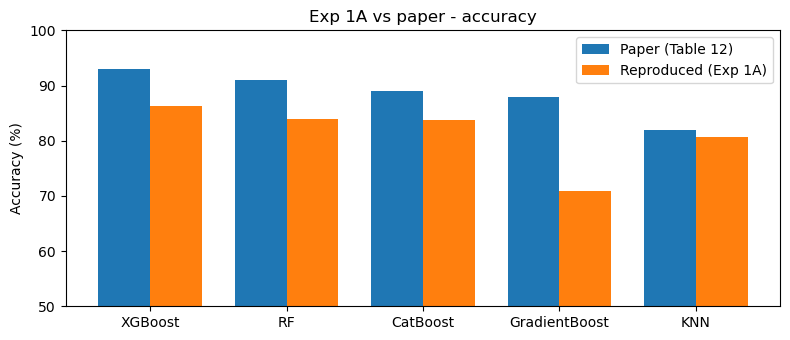

In [26]:
cmp_1a = pd.concat({"Paper (Table 12)": paper_table12,
                    "Reproduced 1A": table_1a[["Precision", "Recall", "F1", "Accuracy"]]}, axis=1)
cmp_1a.to_csv(RESULTS_DIR / "exp1a_vs_paper.csv")
display(cmp_1a)

x = np.arange(len(paper_table12))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(x - 0.19, paper_table12["Accuracy"], 0.38, label="Paper (Table 12)")
ax.bar(x + 0.19, table_1a.loc[paper_table12.index, "Accuracy"], 0.38, label="Reproduced (Exp 1A)")
ax.set_xticks(x); ax.set_xticklabels(paper_table12.index); ax.set_ylabel("Accuracy (%)")
ax.set_ylim(50, 100); ax.legend(); ax.set_title("Exp 1A vs paper - accuracy")
plt.tight_layout(); plt.savefig(FIG_DIR / "exp1a_vs_paper.png", dpi=150); plt.show()

## 4.5 Per-class results (compare with Tables 6, 7, 9, 10, 11)

In [27]:
for name in pc_1a:
    print(f"\n{name} (Exp 1A)")
    display(pc_1a[name])
    pc_1a[name].to_csv(RESULTS_DIR / f"exp1a_per_class_{name}.csv")


KNN (Exp 1A)


,Precision,Recall,F1,AUC,Support
NORM (0),0.827,0.388,0.528,0.821,1814
MI (1),0.775,0.843,0.807,0.963,1813
STTC (2),0.815,0.884,0.848,0.971,1814
HYP (3),0.780,0.996,0.875,0.991,1814
CD (4),0.854,0.925,0.888,0.986,1814



RF (Exp 1A)


,Precision,Recall,F1,AUC,Support
NORM (0),0.806,0.711,0.755,0.941,1814
MI (1),0.814,0.779,0.796,0.961,1813
STTC (2),0.800,0.865,0.831,0.970,1814
HYP (3),0.912,0.954,0.933,0.995,1814
CD (4),0.862,0.891,0.876,0.983,1814



XGBoost (Exp 1A)


,Precision,Recall,F1,AUC,Support
NORM (0),0.781,0.884,0.829,0.973,1814
MI (1),0.860,0.769,0.812,0.958,1813
STTC (2),0.833,0.830,0.832,0.969,1814
HYP (3),0.949,0.946,0.947,0.996,1814
CD (4),0.907,0.888,0.897,0.985,1814



GradientBoost (Exp 1A)


,Precision,Recall,F1,AUC,Support
NORM (0),0.746,0.816,0.779,0.958,1814
MI (1),0.657,0.553,0.600,0.858,1813
STTC (2),0.638,0.698,0.667,0.899,1814
HYP (3),0.743,0.756,0.749,0.941,1814
CD (4),0.760,0.724,0.742,0.929,1814



CatBoost (Exp 1A)


,Precision,Recall,F1,AUC,Support
NORM (0),0.776,0.873,0.822,0.971,1814
MI (1),0.819,0.713,0.762,0.941,1813
STTC (2),0.799,0.807,0.803,0.959,1814
HYP (3),0.917,0.938,0.927,0.992,1814
CD (4),0.878,0.855,0.866,0.977,1814


## 4.6 Confusion matrices (compare with Fig. 7) and ROC of XGBoost (compare with Fig. 8)

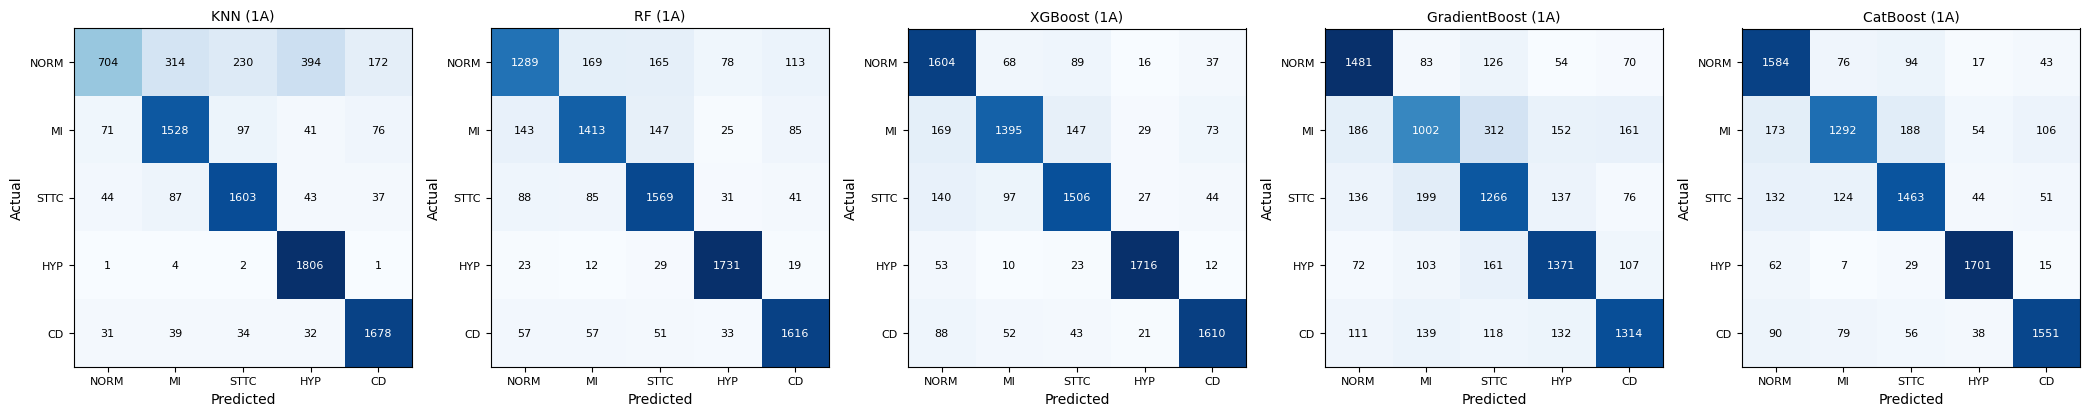

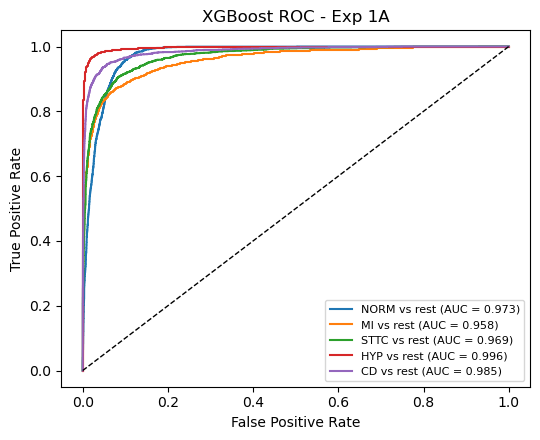

In [28]:
plot_confusion_matrices(list(cms_1a.values()), [f"{m} (1A)" for m in cms_1a], "exp1a_confusion_matrices.png")
plot_multiclass_roc(yte, proba_1a["XGBoost"], "XGBoost ROC - Exp 1A", "exp1a_roc_xgb.png")

## 4.7 Leakage check: recall on real vs synthetic test samples (XGBoost)

,Real test samples,Recall on REAL (%),Synthetic test samples,Recall on SYNTHETIC (%)
Class,,,,
NORM,1814,88.4,0,NaN
MI,511,56.8,1302,84.9
STTC,508,62.8,1306,90.9
HYP,105,48.6,1709,97.4
CD,335,66.3,1479,93.8


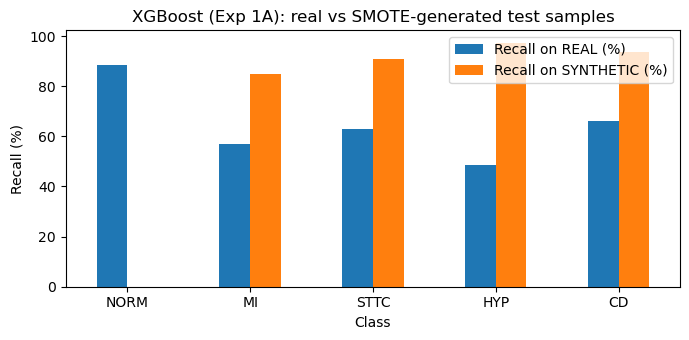

In [29]:
pred_xgb = proba_1a["XGBoost"].argmax(1)
rows = []
for k, c in enumerate(CLASSES):
    real, synth = (~synth_te) & (yte == k), synth_te & (yte == k)
    rows.append({"Class": c,
                 "Real test samples": real.sum(),
                 "Recall on REAL (%)": 100 * (pred_xgb[real] == k).mean(),
                 "Synthetic test samples": synth.sum(),
                 "Recall on SYNTHETIC (%)": 100 * (pred_xgb[synth] == k).mean() if synth.any() else np.nan})
leak = pd.DataFrame(rows).set_index("Class").round(1)
leak.to_csv(RESULTS_DIR / "exp1a_leakage.csv")
display(leak)

leak[["Recall on REAL (%)", "Recall on SYNTHETIC (%)"]].plot.bar(figsize=(7, 3.5), rot=0)
plt.ylabel("Recall (%)"); plt.title("XGBoost (Exp 1A): real vs SMOTE-generated test samples")
plt.tight_layout(); plt.savefig(FIG_DIR / "exp1a_leakage.png", dpi=150); plt.show()

## 4.8 Check of assumption A4: exactly 16 features (mean over beats)

In [30]:
X16 = pd.DataFrame(np.nanmean(X_paper_3d, axis=1)).ffill().bfill().to_numpy()
Xb16, yb16 = SMOTE(random_state=SEED).fit_resample(X16, y)
a, b, ya, yb = train_test_split(Xb16, yb16, test_size=0.2, stratify=yb16, random_state=SEED)
p16 = make_models()["XGBoost"].fit(a, ya).predict_proba(b)
res16 = {k: round(v * 100, 1) for k, v in evaluate(yb, p16.argmax(1), p16).items()}
print("XGBoost, 16 mean features, 1A protocol:", res16)

XGBoost, 16 mean features, 1A protocol: {'Accuracy': 77.3, 'Precision': 77.1, 'Recall': 77.3, 'F1': 77.1, 'AUC': 94.9, 'BalancedAcc': 77.3, 'MCC': 71.6}


# 5. Reproduction With the Protocol the Paper Describes with Experiment 1B

## 5.1 Generic cross-validation function

In [31]:
# Returns a per-fold metric table and the out-of-fold probabilities
def run_cv(X, y, splits, make_pipeline, fit_params_fn=None):
    fold_rows, oof = [], np.zeros((len(y), len(CLASSES)))
    for k, (tr, te) in enumerate(splits):
        pipe = make_pipeline()
        fit_kw = fit_params_fn(y[tr]) if fit_params_fn else {}
        pipe.fit(X[tr], y[tr], **fit_kw)
        proba = pipe.predict_proba(X[te])
        oof[te] = proba
        fold_rows.append({"fold": k + 1, **evaluate(y[te], proba.argmax(1), proba)})
    return pd.DataFrame(fold_rows).set_index("fold"), oof

## 5.2 10-fold stratified CV with scaling and SMOTE inside the training folds

In [32]:
record_splits = list(StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED).split(X_paper, y))

res_1b_folds, oof_1b = {}, {}
if RUN_EXP_1B:
    for name in MODELS_1B:
        t0 = time.time()
        make_pipe = lambda name=name: ImbPipeline([("scaler", StandardScaler()),
                                                    ("smote", SMOTE(random_state=SEED)),
                                                    ("clf", make_models()[name])])
        res_1b_folds[name], oof_1b[name] = run_cv(X_paper, y, record_splits, make_pipe)
        f1 = res_1b_folds[name]["F1"]
        print(f"{name:14s} F1 = {f1.mean():.3f} +/- {f1.std():.3f}  ({(time.time() - t0) / 60:.1f} min)")

KNN            F1 = 0.363 +/- 0.009  (0.1 min)
RF             F1 = 0.507 +/- 0.016  (2.0 min)
XGBoost        F1 = 0.503 +/- 0.011  (2.9 min)
GradientBoost  F1 = 0.514 +/- 0.014  (281.5 min)
CatBoost       F1 = 0.508 +/- 0.013  (21.7 min)


## 5.3 Mean ± standard deviation over the 10 folds

In [102]:
if RUN_EXP_1B:
    mean_1b = pd.DataFrame({m: d.mean() for m, d in res_1b_folds.items()}).T * 100
    std_1b = pd.DataFrame({m: d.std() for m, d in res_1b_folds.items()}).T * 100
    mean_1b.round(2).to_csv(RESULTS_DIR / "exp1b_mean.csv")
    std_1b.round(2).to_csv(RESULTS_DIR / "exp1b_std.csv")
    display(mean_1b.round(1).astype(str) + " +/- " + std_1b.round(1).astype(str))

,Accuracy,Precision,Recall,F1,AUC,BalancedAcc,MCC
KNN,42.9 +/- 1.1,37.0 +/- 0.7,41.8 +/- 1.1,36.3 +/- 0.9,68.9 +/- 0.9,41.8 +/- 1.1,25.3 +/- 1.1
RF,66.5 +/- 0.9,51.7 +/- 2.1,50.5 +/- 1.4,50.7 +/- 1.6,81.5 +/- 0.7,50.5 +/- 1.4,46.6 +/- 1.3
XGBoost,69.4 +/- 0.8,57.4 +/- 3.3,48.2 +/- 1.0,50.3 +/- 1.1,81.5 +/- 0.6,48.2 +/- 1.0,48.5 +/- 1.2
GradientBoost,67.0 +/- 0.9,52.1 +/- 1.5,51.1 +/- 1.3,51.4 +/- 1.4,81.8 +/- 0.8,51.1 +/- 1.3,47.0 +/- 1.3
CatBoost,69.4 +/- 0.8,55.8 +/- 2.6,49.0 +/- 1.2,50.8 +/- 1.3,81.8 +/- 0.7,49.0 +/- 1.2,49.0 +/- 1.3


## 5.4 Confusion matrices, ROC and per-class results (out-of-fold)

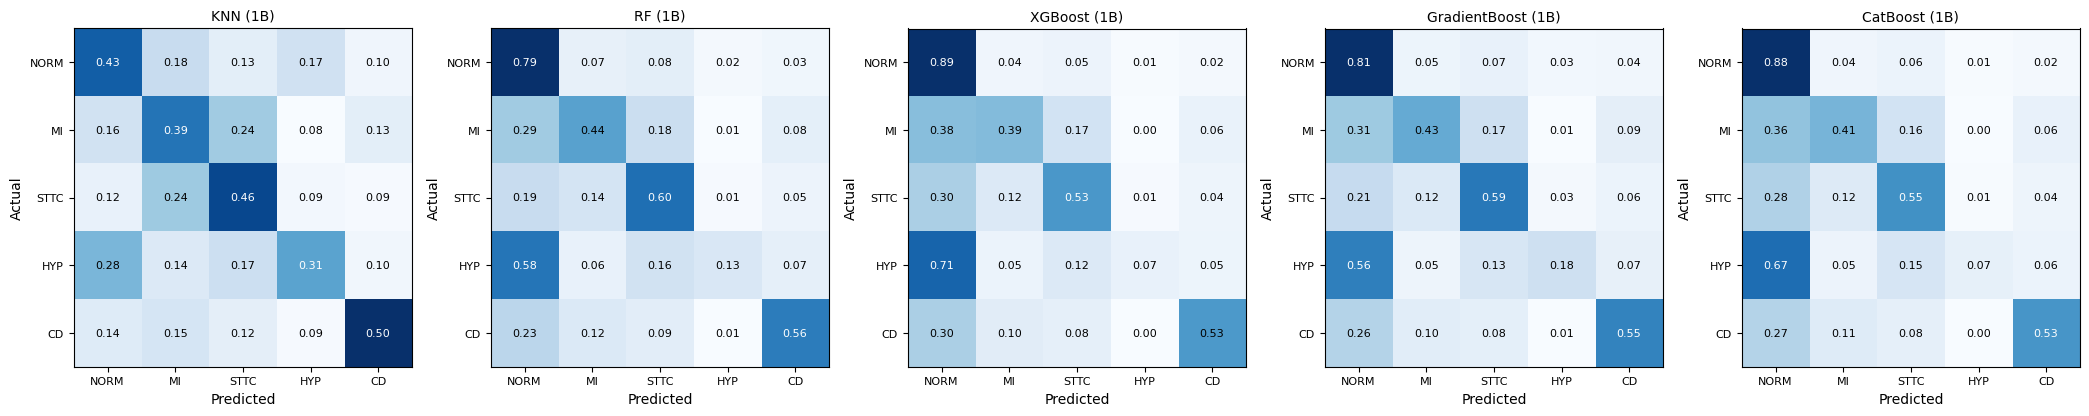

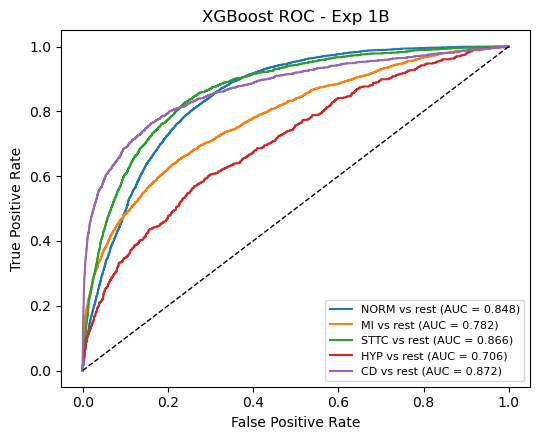

,Precision,Recall,F1,AUC,Support
NORM (0),0.759,0.889,0.819,0.848,9069
MI (1),0.549,0.392,0.457,0.782,2532
STTC (2),0.544,0.534,0.539,0.866,2400
HYP (3),0.322,0.069,0.114,0.706,535
CD (4),0.668,0.525,0.588,0.872,1708


In [103]:
if RUN_EXP_1B:
    cms_1b = {m: confusion_matrix(y, oof_1b[m].argmax(1), labels=range(5)) for m in oof_1b}
    plot_confusion_matrices(list(cms_1b.values()), [f"{m} (1B)" for m in cms_1b],
                            "exp1b_confusion_matrices.png", normalize=True)
    plot_multiclass_roc(y, oof_1b["XGBoost"], "XGBoost ROC - Exp 1B", "exp1b_roc_xgb.png")
    pc_1b = per_class_table(y, oof_1b["XGBoost"].argmax(1), oof_1b["XGBoost"])
    pc_1b.to_csv(RESULTS_DIR / "exp1b_per_class_XGBoost.csv")
    display(pc_1b)

# 6. Part 1 Summary – Paper vs Reproduced Results

In [104]:
summary_p1 = pd.DataFrame({
    "Paper Table 12 (Acc)": paper_table12["Accuracy"],
    "Paper Fig.7 recomputed (Acc)": paper_check["Acc (Fig.7)"],
    "Exp 1A (Acc)": table_1a["Accuracy"],
    "Exp 1A (F1)": table_1a["F1"],
})
if RUN_EXP_1B:
    summary_p1["Exp 1B (Acc)"] = mean_1b["Accuracy"].round(1)
    summary_p1["Exp 1B (F1)"] = mean_1b["F1"].round(1)
    summary_p1["Exp 1B (AUC)"] = mean_1b["AUC"].round(1)
summary_p1 = summary_p1.loc[["XGBoost", "RF", "CatBoost", "GradientBoost", "KNN"]]
summary_p1.to_csv(RESULTS_DIR / "part1_summary.csv")
summary_p1

,Paper Table 12 (Acc),Paper Fig.7 recomputed (Acc),Exp 1A (Acc),Exp 1A (F1),Exp 1B (Acc),Exp 1B (F1),Exp 1B (AUC)
XGBoost,93,92.9,86.3,86.3,69.4,50.3,81.5
RF,91,90.8,84.0,83.8,66.5,50.7,81.5
CatBoost,89,87.7,83.7,83.6,69.4,50.8,81.8
GradientBoost,88,86.6,70.9,70.8,67.0,51.4,81.8
KNN,82,81.7,80.7,78.9,42.9,36.3,68.9


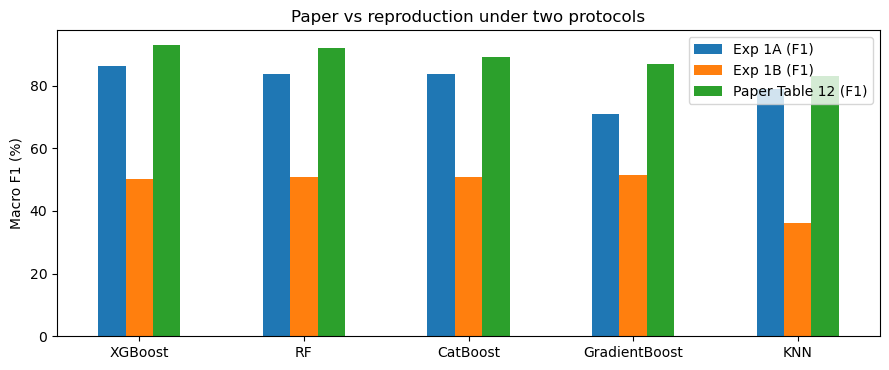

In [105]:
f1_plot = summary_p1.filter(like="(F1)").join(paper_table12["F1"].rename("Paper Table 12 (F1)"))
ax = f1_plot.plot.bar(figsize=(9, 3.8), rot=0)
ax.set_ylabel("Macro F1 (%)"); ax.set_title("Paper vs reproduction under two protocols")
plt.tight_layout(); plt.savefig(FIG_DIR / "part1_summary_f1.png", dpi=150); plt.show()

# 7. Part 2 – Proposed Solution: Leakage-Free, Multi-Lead Median-Beat Features (LF-MBF)

**Differences from the paper:**
1. Patient-wise 10-fold CV with the official PTB-XL `strat_fold`; imputation, scaling and SMOTE fitted inside each training fold
2. Median-beat morphology features for all 12 leads (84 features)
3. Clinical intervals (onset/offset), QTc (Bazett) and heart-rate variability from lead II (12 features)
4. Clinical composite features: Sokolow–Lyon, Cornell, QRS axis, ST extremes, inverted-T and pathological-Q counts (7 features)
5. Statistical comparison with the one-sided Wilcoxon signed-rank test over the 10 folds

## 7.1 Feature definitions and template window

In [106]:
PRE, POST = int(0.25 * FS), int(0.45 * FS)   # template window: 250 ms before R, 450 ms after R

MORPH = ["P_amp", "Q_amp", "R_amp", "S_amp", "ST_lvl", "T_amp", "QRS_net"]
GLOBAL = ["n_beats", "HR", "RR_mean_ms", "SDNN_ms", "RMSSD_ms", "RR_cv",
          "PR_ms", "QRS_ms", "QT_ms", "QTc_ms", "Pdur_ms", "P_detect_rate"]
CLINICAL = ["SokolowLyon", "Cornell", "QRS_axis_deg", "ST_max", "ST_min", "n_T_inverted", "n_Q_path"]
PROPOSED_FEATURES = [f"{l}_{m}" for l in LEADS for m in MORPH] + GLOBAL + CLINICAL
print("Number of proposed features:", len(PROPOSED_FEATURES))


# Milliseconds relative to the R-peak -> index inside the template
def ms2i(ms):
    return PRE + int(round(ms * FS / 1000))


# Value with the largest absolute size (keeps the sign, e.g. inverted T waves)
def signed_extreme(v):
    return v[np.nanargmax(np.abs(v))]

Number of proposed features: 103


## 7.2 Median-beat template for the 12 leads

In [107]:
# Align all beats on the R-peaks of lead II and take the median -> (70 samples, 12 leads)
def median_beat(clean12, r):
    valid = r[(r - PRE >= 0) & (r + POST <= len(clean12))]
    beats = np.stack([clean12[k - PRE:k + POST] for k in valid])
    return np.median(beats, axis=0)

## 7.3 Morphology features for one lead (7 features)

In [108]:
# All amplitudes are measured relative to the PR-segment baseline
def lead_morphology(tpl):
    b = tpl - np.mean(tpl[ms2i(-80):ms2i(-50) + 1])
    r_amp = b[ms2i(-40):ms2i(40) + 1].max()
    s_amp = b[ms2i(0):ms2i(80) + 1].min()
    return [
        signed_extreme(b[ms2i(-250):ms2i(-100) + 1]),   # P amplitude
        b[ms2i(-60):ms2i(0) + 1].min(),                  # Q amplitude
        r_amp,                                           # R amplitude
        s_amp,                                           # S amplitude
        b[ms2i(80):ms2i(120) + 1].mean(),                # ST level
        signed_extreme(b[ms2i(150):ms2i(400) + 1]),     # T amplitude
        r_amp + s_amp,                                   # net QRS deflection
    ]

## 7.4 Rhythm, HRV and clinical intervals from lead II (12 features)

In [109]:
def global_features(ref, r, fs=FS):
    rr_ms = np.diff(r) * 1000 / fs
    _, w = nk.ecg_delineate(ref, r, sampling_rate=fs, method="dwt")
    g = {k: aligned(w[k], len(r)) for k in ["ECG_P_Onsets", "ECG_P_Offsets", "ECG_R_Onsets",
                                            "ECG_R_Offsets", "ECG_T_Offsets", "ECG_P_Peaks"]}

    # Median duration in ms (robust to wrongly delineated beats)
    def dur(a):
        return np.nanmedian(a) * 1000 / fs if np.isfinite(a).any() else np.nan

    qt = dur(g["ECG_T_Offsets"] - g["ECG_R_Onsets"])
    rmssd = np.sqrt(np.mean(np.diff(rr_ms) ** 2)) if len(rr_ms) > 1 else np.nan
    return [len(r), 60000 / rr_ms.mean(), rr_ms.mean(), rr_ms.std(), rmssd, rr_ms.std() / rr_ms.mean(),
            dur(g["ECG_R_Onsets"] - g["ECG_P_Onsets"]),     # PR
            dur(g["ECG_R_Offsets"] - g["ECG_R_Onsets"]),    # QRS
            qt,                                             # QT
            qt / np.sqrt(rr_ms.mean() / 1000),              # QTc (Bazett)
            dur(g["ECG_P_Offsets"] - g["ECG_P_Onsets"]),    # P duration
            np.isfinite(g["ECG_P_Peaks"]).mean()]           # share of beats with a P wave

## 7.5 Clinical composite features (7 features)

In [110]:
def clinical_features(morph):
    L = {name: dict(zip(MORPH, morph[i])) for i, name in enumerate(LEADS)}
    no_avr = [l for l in LEADS if l != "aVR"]
    return [
        abs(L["V1"]["S_amp"]) + max(L["V5"]["R_amp"], L["V6"]["R_amp"]),     # Sokolow-Lyon (LVH)
        L["aVL"]["R_amp"] + abs(L["V3"]["S_amp"]),                           # Cornell voltage (LVH)
        np.degrees(np.arctan2(L["aVF"]["QRS_net"], L["I"]["QRS_net"])),      # QRS axis
        morph[:, 4].max(),                                                   # max ST elevation
        morph[:, 4].min(),                                                   # max ST depression
        sum(L[l]["T_amp"] < -0.1 for l in no_avr),                           # leads with inverted T
        sum(abs(L[l]["Q_amp"]) > 0.25 * max(L[l]["R_amp"], 1e-3) for l in no_avr),  # pathological Q
    ]

## 7.6 Full proposed feature vector for one record (103 features)

In [111]:
def proposed_features(sig12, fs=FS):
    clean12 = np.column_stack([nk.ecg_clean(sig12[:, i], sampling_rate=fs) for i in range(12)])
    ref = clean12[:, LEADS.index("II")]
    _, info = nk.ecg_peaks(ref, sampling_rate=fs)
    r = np.asarray(info["ECG_R_Peaks"], dtype=int)
    if len(r) < 3:
        return np.full(len(PROPOSED_FEATURES), np.nan)
    tpl = median_beat(clean12, r)
    morph = np.array([lead_morphology(tpl[:, i]) for i in range(12)])   # (12 leads, 7 features)
    return np.concatenate([morph.ravel(), global_features(ref, r), clinical_features(morph)]).astype(float)


def extract_proposed_record(filename_lr):
    warnings.filterwarnings("ignore")
    try:
        return proposed_features(load_signal(filename_lr))
    except Exception:
        return np.full(len(PROPOSED_FEATURES), np.nan)

## 7.7 Example: median beats of one record per class (leads II, V1, V5)

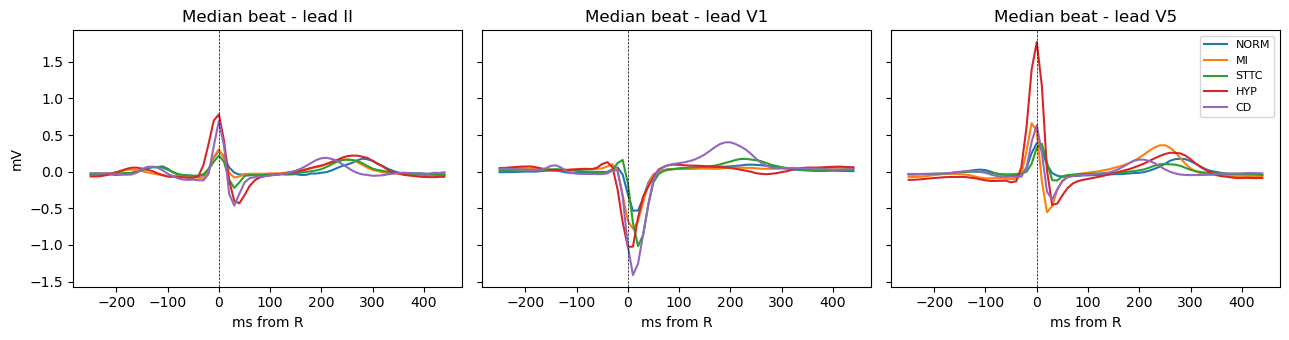

In [112]:
tt = (np.arange(PRE + POST) - PRE) * 1000 / FS
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for cls in CLASSES:
    s = load_signal(meta[meta["label_name"] == cls].iloc[0]["filename_lr"])
    c12 = np.column_stack([nk.ecg_clean(s[:, i], sampling_rate=FS) for i in range(12)])
    _, inf = nk.ecg_peaks(c12[:, 1], sampling_rate=FS)
    tpl = median_beat(c12, np.asarray(inf["ECG_R_Peaks"]))
    for ax, lead in zip(axes, ["II", "V1", "V5"]):
        ax.plot(tt, tpl[:, LEADS.index(lead)], label=cls)
for ax, lead in zip(axes, ["II", "V1", "V5"]):
    ax.axvline(0, color="k", lw=0.5, ls="--"); ax.set_title(f"Median beat - lead {lead}"); ax.set_xlabel("ms from R")
axes[0].set_ylabel("mV"); axes[-1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "median_beats_by_class.png", dpi=150); plt.show()

## 7.8 Extract proposed features for all records (cached)

In [113]:
X_prop = get_features("proposed_features", extract_proposed_record).astype(float)
X_prop[~np.isfinite(X_prop)] = np.nan
print(f"NaN share: {100 * np.isnan(X_prop).mean():.2f}%")

# Sanity check: the Sokolow-Lyon index should be highest for HYP
sl = pd.Series(X_prop[:, PROPOSED_FEATURES.index("SokolowLyon")], index=meta.index)
sl.groupby(meta["label_name"]).median().reindex(CLASSES).round(2).to_frame("Median Sokolow-Lyon (mV)")

Loaded from cache: (16244, 103)
NaN share: 0.11%


,Median Sokolow-Lyon (mV)
label_name,
NORM,1.65
MI,1.47
STTC,1.62
HYP,2.76
CD,1.45


## 7.9 Patient wise folds (official PTB-XL strat_fold):

In [114]:
folds = meta["strat_fold"].to_numpy()
patient_splits = [(np.where(folds != k)[0], np.where(folds == k)[0]) for k in sorted(np.unique(folds))]

# No patient may appear in both the training and the test part of any fold
pid = meta["patient_id"].to_numpy()
assert all(len(set(pid[tr]) & set(pid[te])) == 0 for tr, te in patient_splits)
print("Test records per fold:", [len(te) for _, te in patient_splits])

Test records per fold: [1642, 1619, 1620, 1607, 1607, 1601, 1624, 1637, 1637, 1650]


## 7.10 Pipelines and experimental configurations

In [115]:
# Imputation, scaling and (optionally) SMOTE are fitted on the training fold only
def make_part2_pipeline(model_name, use_smote=True):
    steps = [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=SEED)))
    steps.append(("clf", make_models()[model_name]))
    return ImbPipeline(steps)


# Class weights instead of SMOTE (ablation "Proposed-CW")
def balanced_weights(y_tr):
    return {"clf__sample_weight": compute_sample_weight("balanced", y_tr)}


feature_sets = {
    "Baseline-PW": X_paper,                          # paper features, patient-wise evaluation
    "Proposed": X_prop,                              # LF-MBF + SMOTE
    "Proposed-CW": X_prop,                           # LF-MBF + class weights (ablation)
    "Combined": np.hstack([X_paper, X_prop]),        # both feature sets (ablation)
}

## 7.11 Run patient-wise 10-fold cross-validation

In [116]:
res2_folds, oof2 = {}, {}
for model_name in PART2_MODELS:
    for cfg, X in feature_sets.items():
        t0 = time.time()
        use_smote = cfg != "Proposed-CW"
        key = f"{model_name} | {cfg}"
        res2_folds[key], oof2[key] = run_cv(
            X, y, patient_splits,
            lambda m=model_name, s=use_smote: make_part2_pipeline(m, s),
            None if use_smote else balanced_weights)
        r = res2_folds[key]
        print(f"{key:28s} F1 = {r['F1'].mean():.3f} +/- {r['F1'].std():.3f} | "
              f"AUC = {r['AUC'].mean():.3f}  ({(time.time() - t0) / 60:.1f} min)")

RF | Baseline-PW             F1 = 0.507 +/- 0.022 | AUC = 0.812  (2.1 min)
RF | Proposed                F1 = 0.691 +/- 0.015 | AUC = 0.928  (2.1 min)
RF | Proposed-CW             F1 = 0.653 +/- 0.018 | AUC = 0.930  (0.7 min)
RF | Combined                F1 = 0.681 +/- 0.019 | AUC = 0.923  (3.3 min)
XGBoost | Baseline-PW        F1 = 0.499 +/- 0.025 | AUC = 0.813  (3.0 min)
XGBoost | Proposed           F1 = 0.713 +/- 0.025 | AUC = 0.936  (1.9 min)
XGBoost | Proposed-CW        F1 = 0.718 +/- 0.018 | AUC = 0.937  (1.1 min)
XGBoost | Combined           F1 = 0.708 +/- 0.018 | AUC = 0.937  (5.5 min)


## 7.12 Mean standard deviation over the 10 patient-wise folds:


In [117]:
mean2 = pd.DataFrame({k: d.mean() for k, d in res2_folds.items()}).T * 100
std2 = pd.DataFrame({k: d.std() for k, d in res2_folds.items()}).T * 100
mean2.round(2).to_csv(RESULTS_DIR / "part2_mean.csv")
std2.round(2).to_csv(RESULTS_DIR / "part2_std.csv")
mean2.round(1).astype(str) + " +/- " + std2.round(1).astype(str)

,Accuracy,Precision,Recall,F1,AUC,BalancedAcc,MCC
RF | Baseline-PW,66.4 +/- 1.2,51.4 +/- 2.4,50.7 +/- 2.1,50.7 +/- 2.2,81.2 +/- 1.1,50.7 +/- 2.1,46.5 +/- 1.9
RF | Proposed,77.8 +/- 1.0,68.4 +/- 1.2,70.9 +/- 2.6,69.1 +/- 1.5,92.8 +/- 0.6,70.9 +/- 2.6,65.3 +/- 1.7
RF | Proposed-CW,78.5 +/- 0.9,75.5 +/- 2.1,60.5 +/- 1.8,65.3 +/- 1.8,93.0 +/- 0.7,60.5 +/- 1.8,64.1 +/- 1.4
RF | Combined,77.2 +/- 1.0,67.5 +/- 1.7,69.4 +/- 2.6,68.1 +/- 1.9,92.3 +/- 0.6,69.4 +/- 2.6,64.2 +/- 1.6
XGBoost | Baseline-PW,69.0 +/- 1.5,56.1 +/- 3.4,47.8 +/- 2.3,49.9 +/- 2.5,81.3 +/- 0.9,47.8 +/- 2.3,47.9 +/- 2.5
XGBoost | Proposed,80.7 +/- 1.2,73.6 +/- 2.3,69.5 +/- 2.9,71.3 +/- 2.5,93.6 +/- 0.8,69.5 +/- 2.9,68.7 +/- 2.2
XGBoost | Proposed-CW,80.6 +/- 0.9,73.0 +/- 1.4,71.1 +/- 2.5,71.8 +/- 1.8,93.7 +/- 0.7,71.1 +/- 2.5,69.0 +/- 1.6
XGBoost | Combined,80.4 +/- 0.8,73.7 +/- 1.9,68.5 +/- 1.9,70.8 +/- 1.8,93.7 +/- 0.9,68.5 +/- 1.9,68.1 +/- 1.5


# 8. Part 2: Evaluation and Comparative Analysis

## 8.1 Statistical test: one-sided Wilcoxon signed-rank (proposed vs baseline)

In [118]:
rows = []
for model_name in PART2_MODELS:
    base = res2_folds[f"{model_name} | Baseline-PW"]
    for cfg in ["Proposed", "Proposed-CW", "Combined"]:
        new = res2_folds[f"{model_name} | {cfg}"]
        for metric in ["F1", "AUC", "BalancedAcc", "MCC"]:
            diff = new[metric] - base[metric]
            rows.append({"Model": model_name, "Config": cfg, "Metric": metric,
                         "Mean gain (pts)": 100 * diff.mean(),
                         "Folds improved": f"{(diff > 0).sum()}/10",
                         "Wilcoxon p": stats.wilcoxon(new[metric], base[metric], alternative="greater").pvalue})

stat_table = pd.DataFrame(rows).round(4)
stat_table.to_csv(RESULTS_DIR / "part2_wilcoxon.csv", index=False)
stat_table

,Model,Config,Metric,Mean gain (pts),Folds improved,Wilcoxon p
0,RF,Proposed,F1,18.4391,10/10,0.001
1,RF,Proposed,AUC,11.5689,10/10,0.001
2,RF,Proposed,BalancedAcc,20.2047,10/10,0.001
3,RF,Proposed,MCC,18.8086,10/10,0.001
4,RF,Proposed-CW,F1,14.5859,10/10,0.001
5,RF,Proposed-CW,AUC,11.7681,10/10,0.001
6,RF,Proposed-CW,BalancedAcc,9.8253,10/10,0.001
7,RF,Proposed-CW,MCC,17.6241,10/10,0.001
8,RF,Combined,F1,17.4298,10/10,0.001
9,RF,Combined,AUC,11.0377,10/10,0.001


## 8.2 Fold-level macro F1 (box plot)

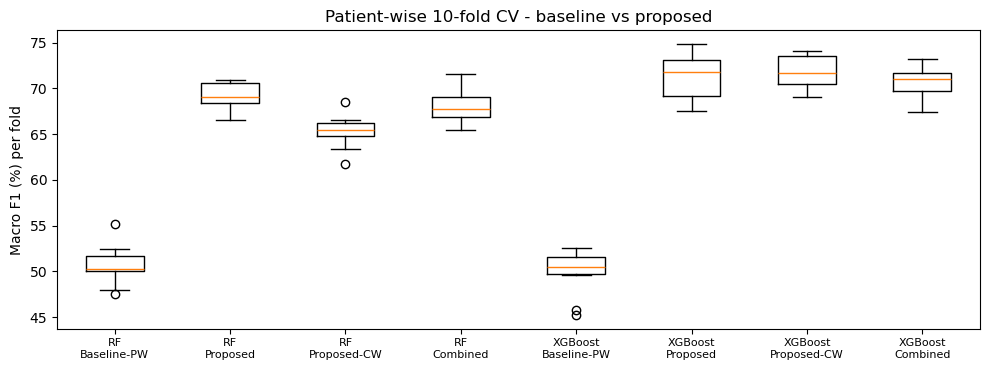

In [119]:
keys = list(res2_folds)
plt.figure(figsize=(10, 3.8))
plt.boxplot([res2_folds[k]["F1"] * 100 for k in keys])
plt.xticks(range(1, len(keys) + 1), [k.replace(" | ", "\n") for k in keys], fontsize=8)
plt.ylabel("Macro F1 (%) per fold"); plt.title("Patient-wise 10-fold CV - baseline vs proposed")
plt.tight_layout(); plt.savefig(FIG_DIR / "part2_boxplot_f1.png", dpi=150); plt.show()

## 8.3 Confusion matrices and ROC: baseline vs proposed

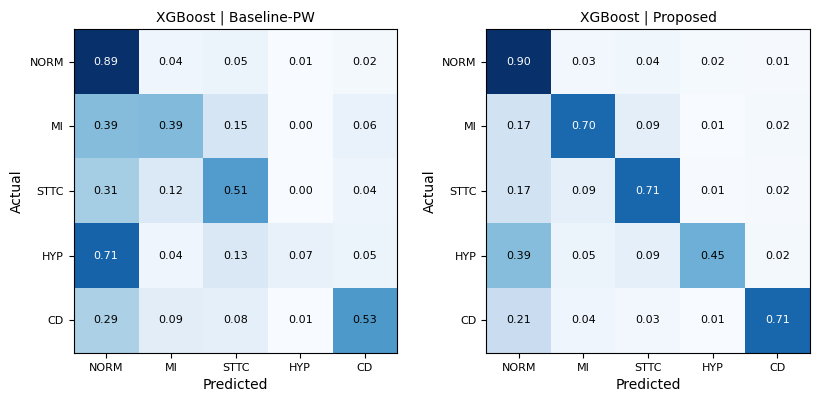

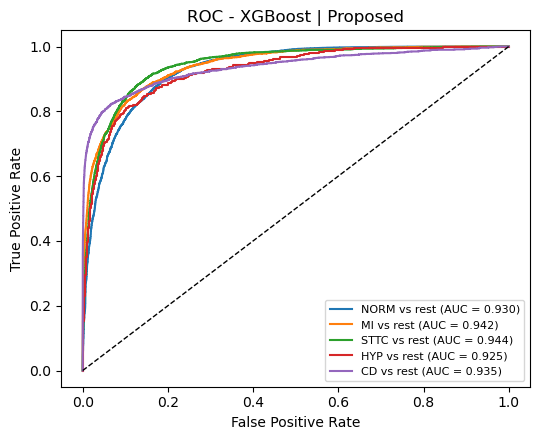

In [120]:
best_model = "XGBoost" if "XGBoost" in PART2_MODELS else PART2_MODELS[0]
kb, kp = f"{best_model} | Baseline-PW", f"{best_model} | Proposed"

plot_confusion_matrices([confusion_matrix(y, oof2[k].argmax(1), labels=range(5)) for k in (kb, kp)],
                        [kb, kp], "part2_confusion_matrices.png", normalize=True)
plot_multiclass_roc(y, oof2[kp], f"ROC - {kp}", "part2_roc_proposed.png")

## 8.4 Per-class comparison

Baseline-PW                               Proposed                \
           Precision Recall     F1    AUC Support Precision Recall     F1   
NORM (0)       0.755  0.887  0.816  0.847    9069     0.851  0.899  0.875   
MI (1)         0.546  0.394  0.458  0.784    2532     0.748  0.705  0.726   
STTC (2)       0.541  0.512  0.526  0.861    2400     0.717  0.712  0.714   
HYP (3)        0.325  0.069  0.114  0.706     535     0.516  0.447  0.479   
CD (4)         0.659  0.528  0.586  0.867    1708     0.850  0.714  0.776   

                         
            AUC Support  
NORM (0)  0.930    9069  
MI (1)    0.942    2532  
STTC (2)  0.944    2400  
HYP (3)   0.925     535  
CD (4)    0.935    1708

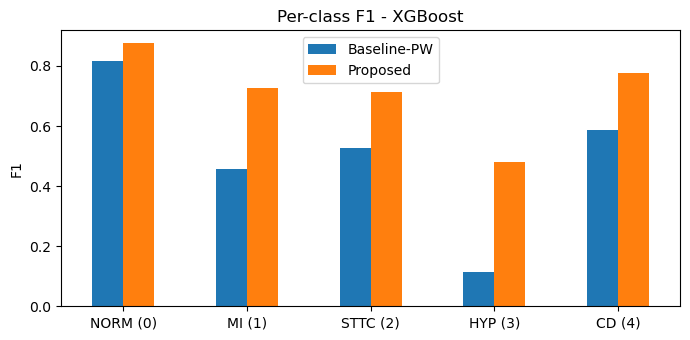

In [121]:
pc_cmp = pd.concat({"Baseline-PW": per_class_table(y, oof2[kb].argmax(1), oof2[kb]),
                    "Proposed": per_class_table(y, oof2[kp].argmax(1), oof2[kp])}, axis=1)
pc_cmp.to_csv(RESULTS_DIR / "part2_per_class.csv")
display(pc_cmp)

pc_cmp.xs("F1", axis=1, level=1).plot.bar(figsize=(7, 3.5), rot=0)
plt.ylabel("F1"); plt.title(f"Per-class F1 - {best_model}")
plt.tight_layout(); plt.savefig(FIG_DIR / "part2_per_class_f1.png", dpi=150); plt.show()

## 8.5 Feature importance (XGBoost trained on folds 1–9)

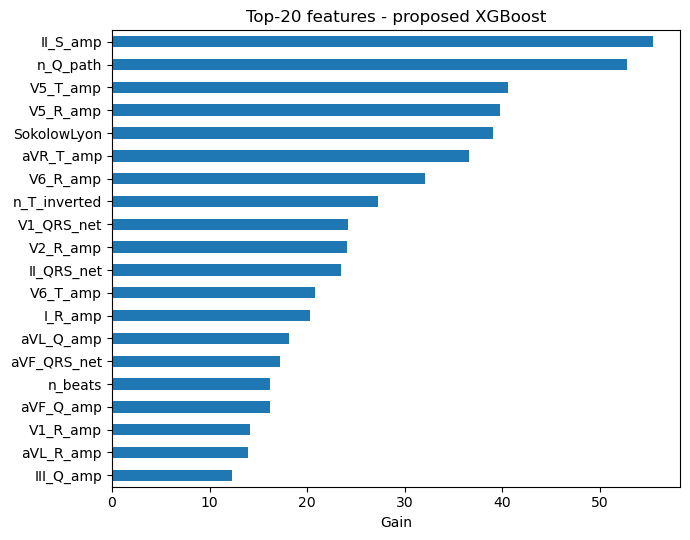

In [122]:
tr, te = patient_splits[-1]
pipe = make_part2_pipeline("XGBoost", True).fit(X_prop[tr], y[tr])
imp = pd.Series(pipe.named_steps["clf"].get_booster().get_score(importance_type="gain"))
imp.index = [PROPOSED_FEATURES[int(i[1:])] for i in imp.index]
top = imp.sort_values(ascending=False).head(20)
top.to_csv(RESULTS_DIR / "part2_top20_features.csv")

top[::-1].plot.barh(figsize=(7, 5.5)); plt.xlabel("Gain")
plt.title("Top-20 features - proposed XGBoost")
plt.tight_layout(); plt.savefig(FIG_DIR / "part2_feature_importance.png", dpi=150); plt.show()

## 8.6 Held-out official test fold (fold 10)

In [123]:
proba10 = pipe.predict_proba(X_prop[te])
fold10 = {k: round(v * 100, 1) for k, v in evaluate(y[te], proba10.argmax(1), proba10).items()}
print("Proposed XGBoost on fold 10:", fold10)

Proposed XGBoost on fold 10: {'Accuracy': 78.8, 'Precision': 73.4, 'Recall': 65.1, 'F1': 68.5, 'AUC': 92.6, 'BalancedAcc': 65.1, 'MCC': 65.5}


## 8.7 Final comparison: paper vs Part 1 vs Part 2

In [124]:
COLS = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
c = paper_check.loc["XGBoost"]
final = [
    {"Setting": "Paper - Table 12", "Protocol": "as reported",
     "Accuracy": 93.0, "Precision": 92.0, "Recall": 90.0, "F1": 93.0, "AUC": np.nan},
    {"Setting": "Paper - recomputed from Fig. 7", "Protocol": "SMOTE before split",
     "Accuracy": c["Acc (Fig.7)"], "Precision": c["Prec (Fig.7)"], "Recall": c["Rec (Fig.7)"],
     "F1": c["F1 (Fig.7)"], "AUC": np.nan},
    {"Setting": "Exp 1A - reproduced", "Protocol": "SMOTE before split, record-wise",
     **table_1a.loc["XGBoost", COLS].to_dict()},
]
if RUN_EXP_1B:
    final.append({"Setting": "Exp 1B - reproduced", "Protocol": "10-fold, SMOTE in fold, record-wise",
                  **mean_1b.loc["XGBoost", COLS].to_dict()})
for cfg in feature_sets:
    protocol = "patient-wise 10-fold, " + ("class weights" if cfg == "Proposed-CW" else "SMOTE in fold")
    final.append({"Setting": f"Part 2 - {cfg}", "Protocol": protocol,
                  **mean2.loc[f"{best_model} | {cfg}", COLS].to_dict()})

final = pd.DataFrame(final).set_index("Setting").round(1)
final.to_csv(RESULTS_DIR / "final_summary.csv")
final

,Protocol,Accuracy,Precision,Recall,F1,AUC
Setting,,,,,,
Paper - Table 12,as reported,93.0,92.0,90.0,93.0,NaN
Paper - recomputed from Fig. 7,SMOTE before split,92.9,93.5,92.9,93.0,NaN
Exp 1A - reproduced,"SMOTE before split, record-wise",86.3,86.6,86.3,86.3,97.6
Exp 1B - reproduced,"10-fold, SMOTE in fold, record-wise",69.4,57.4,48.2,50.3,81.5
Part 2 - Baseline-PW,"patient-wise 10-fold, SMOTE in fold",69.0,56.1,47.8,49.9,81.3
Part 2 - Proposed,"patient-wise 10-fold, SMOTE in fold",80.7,73.6,69.5,71.3,93.6
Part 2 - Proposed-CW,"patient-wise 10-fold, class weights",80.6,73.0,71.1,71.8,93.7
Part 2 - Combined,"patient-wise 10-fold, SMOTE in fold",80.4,73.7,68.5,70.8,93.7
